# Лабораторная работа №3. Квантовое преобразование Фурье. Нахождение собственных чисел

КБ-211 Ставер Леонид

## Задание (Вариант 2)

Дана схема оценки фазы (QPE) с **3 счётными кубитами** и **двумя целевыми кубитами**.

$$|\psi\rangle = \frac{1}{2}(|00\rangle + |01\rangle + |10\rangle + |11\rangle), \qquad U = \begin{pmatrix} 1 & 0 & 0 & 0 \\\\ 0 & e^{i\frac{3\pi}{4}} & 0 & 0 \\\\ 0 & 0 & e^{i\frac{\pi}{4}} & 0 \\\\ 0 & 0 & 0 & -1 \end{pmatrix}$$

Матрица задаётся в коде с помощью `pl = [0, π/4, 0, 0, 3π/4, 0]`.

Необходимо:
1. Проверить унитарность матрицы $U$ с помощью numpy ($UU^\dagger = I$).
2. Реализовать схему QPE.
3. Найти собственные значения и собственные векторы.

Решение выполнено **двумя способами**: с помощью библиотеки `quantumz` и с помощью `qiskit`.

## 1. Проверка унитарности матрицы $U$

Матрица $U$ является диагональной: $U = \text{diag}(1,\ e^{i3\pi/4},\ e^{i\pi/4},\ -1)$.

Унитарность проверяется условием $UU^\dagger = I$.

In [4]:
import numpy as np

theta1 = np.pi / 4       # фаза на первом целевом кубите
theta2 = 3 * np.pi / 4   # фаза на втором целевом кубите

U = np.diag([
    1,
    np.exp(1j * theta2),             # |01> -> e^{i*3pi/4}
    np.exp(1j * theta1),             # |10> -> e^{i*pi/4}
    np.exp(1j * (theta1 + theta2))   # |11> -> e^{i*pi} = -1
])

print('Матрица U:')
print(np.round(U, 6))

product = U @ U.conj().T
print('\nU*U† =')
print(np.round(product, 10))

is_unitary = np.allclose(product, np.eye(4))
print(f'\nU*U† ≈ I: {is_unitary}')
print('Матрица U унитарна.' if is_unitary else 'Матрица U НЕ унитарна!')

Матрица U:
[[ 1.      +0.j        0.      +0.j        0.      +0.j
   0.      +0.j      ]
 [ 0.      +0.j       -0.707107+0.707107j  0.      +0.j
   0.      +0.j      ]
 [ 0.      +0.j        0.      +0.j        0.707107+0.707107j
   0.      +0.j      ]
 [ 0.      +0.j        0.      +0.j        0.      +0.j
  -1.      +0.j      ]]

U*U† =
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]]

U*U† ≈ I: True
Матрица U унитарна.


## 2. Теоретический анализ

Матрица $U = \text{diag}(1,\ e^{i3\pi/4},\ e^{i\pi/4},\ e^{i\pi})$ диагональна, поэтому её собственные векторы — стандартные базисные состояния, а собственные значения — диагональные элементы:

| Собственный вектор | Собственное значение $\lambda$ | Фаза $\varphi$ | $m = \varphi \cdot 8$ |
|---|---|---|---|
| $\lvert u_0\rangle = \lvert 00\rangle$ | $\lambda_0 = 1$ | $\varphi_0 = 0$ | $m_0 = 0$ |
| $\lvert u_1\rangle = \lvert 01\rangle$ | $\lambda_1 = e^{i3\pi/4}$ | $\varphi_1 = 3/8$ | $m_1 = 3$ |
| $\lvert u_2\rangle = \lvert 10\rangle$ | $\lambda_2 = e^{i\pi/4}$ | $\varphi_2 = 1/8$ | $m_2 = 1$ |
| $\lvert u_3\rangle = \lvert 11\rangle$ | $\lambda_3 = -1 = e^{i\pi}$ | $\varphi_3 = 1/2$ | $m_3 = 4$ |

С 3 счётными кубитами результат измерения $m \in \{0,\ldots,7\}$, причём $\varphi = m/8$. Все четыре фазы $0,\ 1/8,\ 3/8,\ 1/2$ точно представимы 3 битами.

Начальное состояние целевого регистра:
$$|\psi\rangle = \frac{1}{2}(|00\rangle + |01\rangle + |10\rangle + |11\rangle) = \frac{1}{2}(|u_0\rangle + |u_1\rangle + |u_2\rangle + |u_3\rangle)$$

QPE даст суперпозицию $\frac{1}{2}(|0\rangle|u_0\rangle + |3\rangle|u_1\rangle + |1\rangle|u_2\rangle + |4\rangle|u_3\rangle)$, поэтому при измерении счётного регистра ожидаем каждое из значений $m = 0, 1, 3, 4$ с вероятностью $P = 1/4$.

---

# Вариант 1: Реализация на `quantumz`

## 2.1. Импорт и параметры

In [5]:
from quantumz import initq, H, CU, CRt, multi_measure, sw2
import cmath as cm
import matplotlib.pyplot as plt

n_count  = 3   # счётные кубиты: 0, 1, 2
n_target = 2   # целевые кубиты: 3, 4
n_total  = n_count + n_target   # 5 кубитов всего

# pl = [0, pi/4, 0,  0, 3pi/4, 0]
# CU(mlist, 3, 0, pi/4, 0)  -> фаза e^{i*pi/4}  на кубите 3
# CU(mlist, 4, 0, 3pi/4, 0) -> фаза e^{i*3pi/4} на кубите 4
theta1_qz = cm.pi / 4
theta2_qz = 3 * cm.pi / 4

print(f'Счётные кубиты : 0-{n_count - 1}')
print(f'Целевые кубиты : {n_count}-{n_total - 1}')
print(f'Всего кубитов  : {n_total}')
print(f'theta1 = pi/4  = {theta1_qz.real:.9f}   ->  phi2 = 1/8, m2 = 1')
print(f'theta2 = 3pi/4 = {theta2_qz.real:.9f}   ->  phi1 = 3/8, m1 = 3')

Счётные кубиты : 0-2
Целевые кубиты : 3-4
Всего кубитов  : 5
theta1 = pi/4  = 0.785398163   ->  phi2 = 1/8, m2 = 1
theta2 = 3pi/4 = 2.356194490   ->  phi1 = 3/8, m1 = 3


## 2.2. Управляемый вентиль $CU^{2^k}$ для двухкубитной цели

Управляемый $CU^{2^k}$: счётный кубит `j` управляет двумя независимыми фазовыми гейтами `CU` на целевых кубитах 3 и 4.

In [6]:
def controlled_U_power_qz(q, control, power):
    """Управляемый U^(2^power): кубит control управляет фазами на кубитах 3 и 4."""
    p1 = (2 ** power) * theta1_qz.real
    p2 = (2 ** power) * theta2_qz.real
    q = CU(q, [control], n_count,     0, p1, 0)
    q = CU(q, [control], n_count + 1, 0, p2, 0)
    return q

## 2.3. Алгоритм QPE на `quantumz`

| Этап | Действие |
|---|---|
| 1. Инициализация | $\lvert 0\rangle^{\otimes 3}\lvert 00\rangle \to \lvert 0\rangle^{\otimes 3}\lvert \psi\rangle$, где $\lvert \psi\rangle = (H{\otimes}H)\lvert 00\rangle$ |
| 2. Адамар | $H^{\otimes 3}$ на счётных кубитах |
| 3. Управляемые $U^{2^k}$ | Кубит $j$ управляет $U^{2^j}$ на целевых кубитах, $j = 0, 1, 2$ |
| 4. Обратное КПФ | $\text{QFT}^{-1}$ на счётном регистре |
| 5. Измерение | Измеряем счётные кубиты $\to m$, фаза $\varphi = m/8$ |

In [7]:
# 1. Инициализация: |00000> -> |000>|psi>, |psi> = H(x)H|00>
q = initq(n_total)
q = H(q, n_count)       # H на кубите 3
q = H(q, n_count + 1)   # H на кубите 4

print('После инициализации целевого регистра (ненулевые амплитуды):')
for k, v in sorted(q.items()):
    if abs(v) > 1e-8:
        print(f'  {k}: {round(v.real, 5)}')

# 2. Адамар на счётных кубитах
for i in range(n_count):
    q = H(q, i)

# 3. Управляемые U^{2^j}
for j in range(n_count):
    q = controlled_U_power_qz(q, j, j)

print(f'\nПосле управляемых U^{{2^k}} (до обратного QFT):')
nonzero = {k: v for k, v in q.items() if abs(v) > 1e-8}
print(f'  Число ненулевых амплитуд: {len(nonzero)}')

# 4. Обратное QFT на счётном регистре (кубиты 0..2)
for i in range(n_count - 1, -1, -1):
    for k in range(n_count - i, 1, -1):
        q = CRt(q, [i + k - 1], i, k)
    q = H(q, i)

# Swap счётного регистра (кубит 0 <-> кубит 2)
for i in range(n_count // 2):
    q = sw2(q, i, n_count - 1 - i)

# 5. Измерение счётного регистра
probs, states = multi_measure(q, list(range(n_count)))

print('\nРезультаты измерения счётного регистра:')
print(f'{"Состояние":>10} | {"m":>4} | {"P":>10} | {"phi=m/8":>9} | Собственное значение')
print('-' * 62)
for k in sorted(probs):
    if probs[k] > 1e-6:
        bits     = k[1:-1]
        bits_rev = bits[::-1]   # кубит 0 - LSB
        m   = int(bits_rev, 2)
        phi = m / 2**n_count
        print(f'{k:>10} | {m:>4} | {probs[k]:>10.6f} | {phi:>9.6f} | e^(2*pi*i*{m}/8)')

После инициализации целевого регистра (ненулевые амплитуды):
  |00000>: 0.5
  |00001>: 0.5
  |00010>: 0.5
  |00011>: 0.5

После управляемых U^{2^k} (до обратного QFT):
  Число ненулевых амплитуд: 32

Результаты измерения счётного регистра:
 Состояние |    m |          P |   phi=m/8 | Собственное значение
--------------------------------------------------------------
     |000> |    0 |   0.250000 |  0.000000 | e^(2*pi*i*0/8)
     |001> |    4 |   0.250000 |  0.500000 | e^(2*pi*i*4/8)
     |100> |    1 |   0.250000 |  0.125000 | e^(2*pi*i*1/8)
     |110> |    3 |   0.250000 |  0.375000 | e^(2*pi*i*3/8)


## 2.4. Визуализация результатов (quantumz)

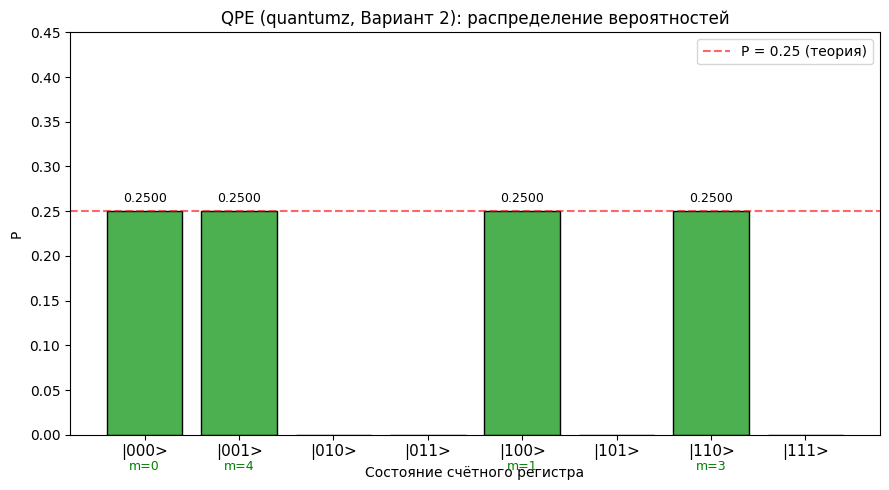

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

all_states_qz = [f'|{format(i, f"0{n_count}b")}>' for i in range(2**n_count)]
probs_qz = {s: probs.get(s, 0) for s in all_states_qz}

values_qz = [probs_qz[s] for s in all_states_qz]
colors_qz = ['#4CAF50' if v > 0.1 else '#BDBDBD' for v in values_qz]

ax.bar(all_states_qz, values_qz, color=colors_qz, edgecolor='black')
ax.set_ylim(0, 0.45)
ax.set_ylabel('P')
ax.set_xlabel('Состояние счётного регистра')
ax.set_title('QPE (quantumz, Вариант 2): распределение вероятностей')
ax.tick_params(axis='x', labelsize=11)
ax.axhline(y=0.25, color='red', linestyle='--', alpha=0.6, label='P = 0.25 (теория)')
ax.legend()

for i, (s, val) in enumerate(zip(all_states_qz, values_qz)):
    if val > 0.05:
        bits_rev = s[1:-1][::-1]
        m = int(bits_rev, 2)
        ax.text(i, val + 0.01, f'{val:.4f}', ha='center', fontsize=9)
        ax.text(i, -0.04, f'm={m}', ha='center', fontsize=9, color='green')

plt.tight_layout()
plt.show()

---

# Вариант 2: Реализация на `qiskit`

## 3.1. Построение схемы QPE

In [10]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import UnitaryGate
import numpy as np

n_count_q = 3
theta1_q  = np.pi / 4
theta2_q  = 3 * np.pi / 4

# В qiskit target[0] - LSB, target[1] - MSB:
#   index 0: |00>, index 1: |01> (target[0]=1), index 2: |10> (target[1]=1), index 3: |11>
matrix_U = np.diag([
    1,
    np.exp(1j * theta2_q),              # target[0]=1 -> e^{i*3pi/4}
    np.exp(1j * theta1_q),              # target[1]=1 -> e^{i*pi/4}
    np.exp(1j * (theta1_q + theta2_q))  # оба = 1    -> -1
])

print('Матрица U (qiskit):')
print(np.round(matrix_U, 6))
print(f'Проверка унитарности: {np.allclose(matrix_U @ matrix_U.conj().T, np.eye(4))}')

qr_count  = QuantumRegister(n_count_q, 'count')
qr_target = QuantumRegister(2, 'target')
cr        = ClassicalRegister(n_count_q, 'result')
qc        = QuantumCircuit(qr_count, qr_target, cr)

# 1. Подготовка |psi> = H(x)H|00>
qc.h(qr_target[0])
qc.h(qr_target[1])

# 2. Адамар на счётных кубитах
for i in range(n_count_q):
    qc.h(qr_count[i])

# 3. Управляемые U^{2^k} через UnitaryGate
for j in range(n_count_q):
    matrix_Uk = np.linalg.matrix_power(matrix_U, 2**j)
    gate_Uk   = UnitaryGate(matrix_Uk, label=f'U^{2**j}')
    c_gate_Uk = gate_Uk.control(1)
    qc.append(c_gate_Uk, [qr_count[j], qr_target[0], qr_target[1]])

qc.barrier()

# 4. Обратное QFT на счётном регистре (3 кубита)
for i in range(n_count_q - 1, -1, -1):
    for k in range(n_count_q - 1, i, -1):
        angle = -2 * np.pi / (2 ** (k - i + 1))
        qc.cp(angle, qr_count[k], qr_count[i])
    qc.h(qr_count[i])

for i in range(n_count_q // 2):
    qc.swap(qr_count[i], qr_count[n_count_q - 1 - i])

# 5. Измерение счётного регистра
qc.measure(qr_count, cr)

print('\nСхема QPE (qiskit):')
print(qc.draw(output='text', fold=100))

Матрица U (qiskit):
[[ 1.      +0.j        0.      +0.j        0.      +0.j
   0.      +0.j      ]
 [ 0.      +0.j       -0.707107+0.707107j  0.      +0.j
   0.      +0.j      ]
 [ 0.      +0.j        0.      +0.j        0.707107+0.707107j
   0.      +0.j      ]
 [ 0.      +0.j        0.      +0.j        0.      +0.j
  -1.      +0.j      ]]
Проверка унитарности: True

Схема QPE (qiskit):
          ┌───┐                         ░                                         ┌───┐   ┌─┐   
 count_0: ┤ H ├───■─────────────────────░──────────────────────■─────────■────────┤ H ├─X─┤M├───
          ├───┤   │                     ░                ┌───┐ │         │P(-π/2) └┬─┬┘ │ └╥┘   
 count_1: ┤ H ├───┼───────■─────────────░───────■────────┤ H ├─┼─────────■─────────┤M├──┼──╫────
          ├───┤   │       │             ░ ┌───┐ │P(-π/2) └───┘ │P(-π/4)            └╥┘  │  ║ ┌─┐
 count_2: ┤ H ├───┼───────┼───────■─────░─┤ H ├─■──────────────■────────────────────╫───X──╫─┤M├
          ├───┤┌──┴───┐┌──┴

## 3.2. Запуск симуляции и результаты

In [11]:
simulator   = AerSimulator()
qc_compiled = transpile(qc, simulator)
result      = simulator.run(qc_compiled, shots=8192).result()
counts      = result.get_counts()

print('Результаты измерений (qiskit):')
print(f'{"Биты":>6} | {"m":>4} | {"Частота":>8} | {"P":>10} | {"phi=m/8":>9} | Собственное значение')
print('-' * 65)
for bits in sorted(counts, key=lambda x: counts[x], reverse=True):
    m   = int(bits, 2)
    p   = counts[bits] / 8192
    phi = m / 2**n_count_q
    print(f'{bits:>6} | {m:>4} | {counts[bits]:>8} | {p:>10.6f} | {phi:>9.6f} | e^(2*pi*i*{m}/8)')

Результаты измерений (qiskit):
  Биты |    m |  Частота |          P |   phi=m/8 | Собственное значение
-----------------------------------------------------------------
   100 |    4 |     2061 |   0.251587 |  0.500000 | e^(2*pi*i*4/8)
   011 |    3 |     2055 |   0.250854 |  0.375000 | e^(2*pi*i*3/8)
   000 |    0 |     2051 |   0.250366 |  0.000000 | e^(2*pi*i*0/8)
   001 |    1 |     2025 |   0.247192 |  0.125000 | e^(2*pi*i*1/8)


## 3.3. Визуализация результатов (qiskit)

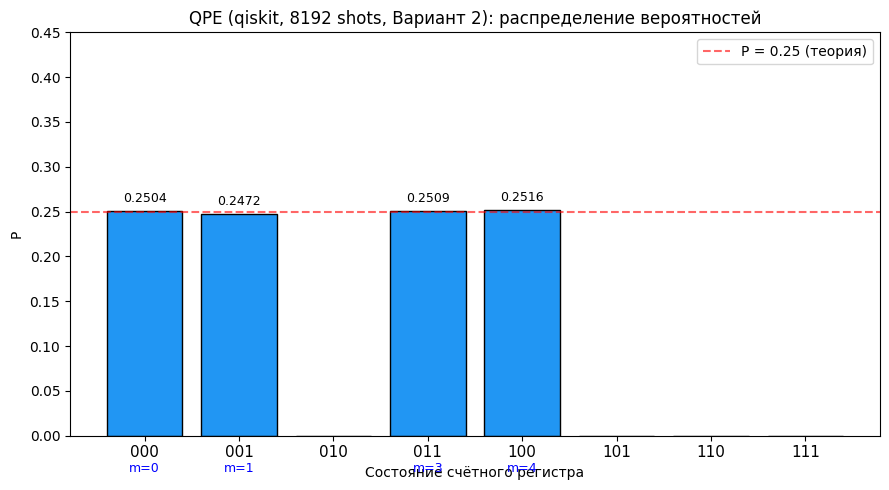

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

all_states_q = [format(i, f'0{n_count_q}b') for i in range(2**n_count_q)]
probs_qiskit = {s: counts.get(s, 0) / 8192 for s in all_states_q}

values_q = [probs_qiskit[s] for s in all_states_q]
colors_q = ['#2196F3' if v > 0.1 else '#BDBDBD' for v in values_q]

ax.bar(all_states_q, values_q, color=colors_q, edgecolor='black')
ax.set_ylim(0, 0.45)
ax.set_ylabel('P')
ax.set_xlabel('Состояние счётного регистра')
ax.set_title('QPE (qiskit, 8192 shots, Вариант 2): распределение вероятностей')
ax.tick_params(axis='x', labelsize=11)
ax.axhline(y=0.25, color='red', linestyle='--', alpha=0.6, label='P = 0.25 (теория)')
ax.legend()

for i, (s, val) in enumerate(zip(all_states_q, values_q)):
    if val > 0.05:
        m = int(s, 2)
        ax.text(i, val + 0.01, f'{val:.4f}', ha='center', fontsize=9)
        ax.text(i, -0.04, f'm={m}', ha='center', fontsize=9, color='blue')

plt.tight_layout()
plt.show()

---

## 4. Сравнение результатов двух реализаций

In [13]:
print('=' * 65)
print('  Сравнение результатов: quantumz vs qiskit')
print('=' * 65)

print('\nТеоретическое предсказание:')
theory = [(0, 0.0, '1',          '|00>'),
          (1, 1/8, 'e^(i*pi/4)',  '|10>'),
          (3, 3/8, 'e^(i*3pi/4)', '|01>'),
          (4, 1/2, '-1',           '|11>')]
for m, phi, lam, evec in theory:
    print(f'  m={m}, phi={phi:.5f}, lambda={lam:>14}, |u>={evec}, P_theor=0.25')

print('\nquantumz (точная симуляция):')
for k in sorted(probs):
    if probs[k] > 1e-6:
        bits     = k[1:-1]
        bits_rev = bits[::-1]
        m   = int(bits_rev, 2)
        phi = m / 2**n_count
        print(f'  m={m:>2}, phi={phi:.5f}, lambda=e^(2*pi*i*{phi:.5f}), P={probs[k]:.6f}')

print('\nqiskit (8192 shots):')
for bits in sorted(counts, key=lambda x: counts[x], reverse=True):
    if counts[bits] > 10:
        m   = int(bits, 2)
        phi = m / 2**n_count_q
        p   = counts[bits] / 8192
        print(f'  m={m:>2}, phi={phi:.5f}, lambda=e^(2*pi*i*{phi:.5f}), P={p:.4f}')

  Сравнение результатов: quantumz vs qiskit

Теоретическое предсказание:
  m=0, phi=0.00000, lambda=             1, |u>=|00>, P_theor=0.25
  m=1, phi=0.12500, lambda=    e^(i*pi/4), |u>=|10>, P_theor=0.25
  m=3, phi=0.37500, lambda=   e^(i*3pi/4), |u>=|01>, P_theor=0.25
  m=4, phi=0.50000, lambda=            -1, |u>=|11>, P_theor=0.25

quantumz (точная симуляция):
  m= 0, phi=0.00000, lambda=e^(2*pi*i*0.00000), P=0.250000
  m= 4, phi=0.50000, lambda=e^(2*pi*i*0.50000), P=0.250000
  m= 1, phi=0.12500, lambda=e^(2*pi*i*0.12500), P=0.250000
  m= 3, phi=0.37500, lambda=e^(2*pi*i*0.37500), P=0.250000

qiskit (8192 shots):
  m= 4, phi=0.50000, lambda=e^(2*pi*i*0.50000), P=0.2516
  m= 3, phi=0.37500, lambda=e^(2*pi*i*0.37500), P=0.2509
  m= 0, phi=0.00000, lambda=e^(2*pi*i*0.00000), P=0.2504
  m= 1, phi=0.12500, lambda=e^(2*pi*i*0.12500), P=0.2472


## 4.1. Итог: собственные значения матрицы $U$

По результатам алгоритма QPE получены четыре собственных значения:

- $\lambda_0 = e^{2\pi i \cdot 0} = 1$, соответствует $m = 0$, $P \approx 0.25$;
- $\lambda_1 = e^{2\pi i \cdot \frac{3}{8}} = e^{i\frac{3\pi}{4}}$, соответствует $m = 3$, $P \approx 0.25$;
- $\lambda_2 = e^{2\pi i \cdot \frac{1}{8}} = e^{i\frac{\pi}{4}}$, соответствует $m = 1$, $P \approx 0.25$;
- $\lambda_3 = e^{2\pi i \cdot \frac{1}{2}} = -1$, соответствует $m = 4$, $P \approx 0.25$.

Соответствующие собственные векторы:

$$
|u_0\rangle = |00\rangle, \quad |u_1\rangle = |01\rangle, \quad |u_2\rangle = |10\rangle, \quad |u_3\rangle = |11\rangle.
$$

Обе реализации — `quantumz` и `qiskit` — дают совпадающие результаты.

## 5. Выводы

В ходе лабораторной работы реализован алгоритм оценки квантовой фазы (QPE) для нахождения собственных значений двухкубитной унитарной матрицы
$$U = \text{diag}\!\left(1,\ e^{i3\pi/4},\ e^{i\pi/4},\ -1\right)$$
с использованием 3 счётных кубитов и 2 целевых кубитов.

Предварительно подтверждена унитарность матрицы $U$ ($UU^\dagger = I$). Теоретический анализ показал, что собственные векторы $U$ — стандартные базисные состояния $|00\rangle, |01\rangle, |10\rangle, |11\rangle$, а соответствующие фазы $\varphi \in \{0,\ 1/8,\ 3/8,\ 1/2\}$ точно представимы 3 битами ($2^3 = 8$).

Начальное состояние $|\psi\rangle = \frac{1}{2}(|00\rangle + |01\rangle + |10\rangle + |11\rangle)$ — равная суперпозиция всех четырёх собственных векторов, поэтому QPE обнаруживает каждую фазу с равной вероятностью $P = 1/4$.

Реализация выполнена двумя независимыми способами:
- **`quantumz`** — точная амплитудная симуляция. Управляемый $U^{2^k}$ реализован двумя независимыми фазовыми вентилями `CU` на двух целевых кубитах.
- **`qiskit`** — статистическая симуляция (AerSimulator, 8192 прогонов).

Оба метода дали совпадающие результаты, полностью соответствующие теоретическому предсказанию. Алгоритм QPE позволяет за один запуск определить все собственные значения унитарного оператора с точностью, определяемой числом счётных кубитов. В нашем случае 3 кубита обеспечивают разрешение $1/8$, что достаточно для точного определения всех четырёх фаз.